<a href="https://colab.research.google.com/github/kevinketerlondon-tech/Data-Analyst-portfolio/blob/main/week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = SparkSession.builder \
    .appName("Logistic Regression") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

In [ ]:
dff = spark.read.csv('/content/drive/MyDrive/customer_segmentation_dataset.csv',inferSchema=True, header =True)

In [ ]:
print(dff.count())

2000000


In [ ]:
dff.show()

+---+-------------+--------------+-----------------+-------------------+----------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|
+---+-------------+--------------+-----------------+-------------------+----------------+
| 22|       113441|            19|                2|                 44|       Low Value|
| 47|        85415|            74|                7|                 11|    Medium Value|
| 60|        78075|            18|               19|                 37|       Low Value|
| 44|        89388|            84|               10|                 15|      High Value|
| 37|        94910|            85|               15|                 31|      High Value|
| 29|        83134|            64|               12|                  8|    Medium Value|
| 46|        52488|            81|               14|                 39|      High Value|
| 50|        90449|            22|               15|                  8|       Low Value|
| 68|     

In [ ]:
dff.select("customer_segment").distinct().show()
dff.printSchema()

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
print("yes",dff.select("customer_segment").where("customer_segment=='High Value'").count())
print("No",dff.select("customer_segment").where("customer_segment=='Low Value'").count())
print("alright",dff.select("customer_segment").where("customer_segment=='Medium Value'").count())

yes 485871
No 1008881
alright 505248


In [ ]:
[ print("annual_income",dff[t[0]].name,dff.select(t[0]).distinct().show()) for t in dff.dtypes if t[1]=='string']

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

annual_income <bound method Column.name of Column<'customer_segment'>> None


[None]

In [ ]:
numeric_features = [t[0] for t in dff.dtypes if t[1] == 'int']
dff.select(numeric_features).describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
age,2000000,43.477824,15.00015569010386,18,69
annual_income,2000000,85001.7181955,37527.92677419766,20000,149999
spending_score,2000000,50.049344,28.567160870674087,1,99
years_as_customer,2000000,9.987763,5.478078153924148,1,19
number_of_purchases,2000000,25.019448,14.143843812749502,1,49


In [ ]:
print("total records:",dff.count())
[print(col,"Total null values",dff.where(dff[col].isNull()).count()) for col in dff.columns]

total records: 2000000
age Total null values 0
annual_income Total null values 0
spending_score Total null values 0
years_as_customer Total null values 0
number_of_purchases Total null values 0
customer_segment Total null values 0


[None, None, None, None, None, None]

In [ ]:
df= dff.select('age','annual_income', 'years_as_customer','number_of_purchases', 'spending_score', 'customer_segment')
cols = df.columns
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler

# Define truly categorical columns for OneHotEncoding (those with limited distinct values)
categoricalColumns = ['age', 'years_as_customer', 'number_of_purchases', 'spending_score']
stages = []
for categoricalCol in categoricalColumns:
    stringIndexer = StringIndexer(inputCol = categoricalCol, outputCol = categoricalCol + 'Index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    print(stringIndexer.getOutputCol())
    stages += [stringIndexer, encoder]

# Label encoding for the target variable
label_stringIdx = StringIndexer(inputCol = 'customer_segment', outputCol = 'label')
print(label_stringIdx)
stages += [label_stringIdx]

# Define numerical columns to be included directly (e.g., annual_income due to high cardinality)
numericCols = ['annual_income']

# Assemble all features: one-hot encoded categorical features + numerical features
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericCols
print(assemblerInputs)
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

ageIndex
years_as_customerIndex
number_of_purchasesIndex
spending_scoreIndex
StringIndexer_df0e843c075c
['ageclassVec', 'years_as_customerclassVec', 'number_of_purchasesclassVec', 'spending_scoreclassVec', 'annual_income']


In [ ]:
from pyspark.ml import Pipeline

# Re-create df with only the original columns to ensure no existing transformed columns
df = dff.select('age','annual_income', 'years_as_customer','number_of_purchases', 'spending_score', 'customer_segment')

pipeline = Pipeline(stages = stages)
pipelineModel= pipeline.fit(df)
df = pipelineModel.transform(df)
df.show(12,True)

+---+-------------+-----------------+-------------------+--------------+----------------+--------+---------------+----------------------+-------------------------+------------------------+---------------------------+-------------------+----------------------+-----+--------------------+
|age|annual_income|years_as_customer|number_of_purchases|spending_score|customer_segment|ageIndex|    ageclassVec|years_as_customerIndex|years_as_customerclassVec|number_of_purchasesIndex|number_of_purchasesclassVec|spending_scoreIndex|spending_scoreclassVec|label|            features|
+---+-------------+-----------------+-------------------+--------------+----------------+--------+---------------+----------------------+-------------------------+------------------------+---------------------------+-------------------+----------------------+-----+--------------------+
| 22|       113441|                2|                 44|            19|       Low Value|    12.0|(51,[12],[1.0])|                   4.0|  

In [ ]:
print(df.select("features").show(1))
print(cols)

+--------------------+
|            features|
+--------------------+
|(216,[12,55,113,1...|
+--------------------+
only showing top 1 row
None
['age', 'annual_income', 'years_as_customer', 'number_of_purchases', 'spending_score', 'customer_segment']


In [ ]:
selectedCols = ['label', 'features'] + cols
dfSelected = df.select(selectedCols)
dfSelected.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
from pyspark.ml.classification import OneVsRest
from pyspark.ml.classification import LogisticRegression
train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
lr = LogisticRegression(maxIter=100, \

                        featuresCol="features", \

                        labelCol='label')
ovr = OneVsRest(classifier=lr, \
                labelCol='label', \
                featuresCol='features')

In [ ]:
ovrModel = ovr.fit(train)
predictionsovr = ovrModel.transform(test)
predictionsovr.show(10)

+-----+--------------------+---+-------------+-----------------+-------------------+--------------+----------------+--------------------+----------+
|label|            features|age|annual_income|years_as_customer|number_of_purchases|spending_score|customer_segment|       rawPrediction|prediction|
+-----+--------------------+---+-------------+-----------------+-------------------+--------------+----------------+--------------------+----------+
|  0.0|(216,[0,51,69,129...| 29|        31424|                1|                 45|            29|       Low Value|[19.7571663086218...|       0.0|
|  0.0|(216,[0,51,69,187...| 29|       132289|                1|                 45|            49|       Low Value|[19.7648610888131...|       0.0|
|  0.0|(216,[0,51,69,212...| 29|       134831|                1|                 45|             2|       Low Value|[19.7648595980687...|       0.0|
|  0.0|(216,[0,51,69,213...| 29|        63310|                1|                 45|             3|       

In [ ]:
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
prediction_and_labels = predictionsovr.select("prediction", "label") \
    .withColumnRenamed("indexedLabel", "label") \
    .toPandas()

In [ ]:
confusion_matrix = pd.crosstab(prediction_and_labels['label'], prediction_and_labels['prediction'], rownames=['Actual'], colnames=['Predicted'])

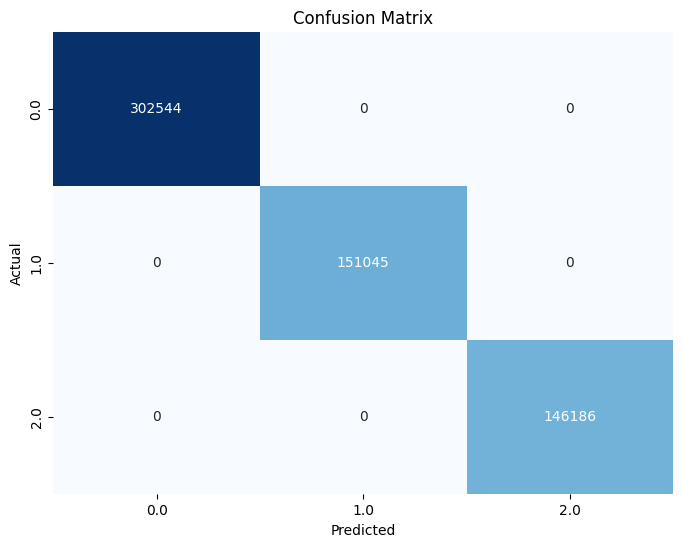

Test accuracy =   1.0


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

evaluator = MulticlassClassificationEvaluator(\
labelCol="label", predictionCol="prediction",\
metricName="accuracy")
accuracy = evaluator.evaluate(predictionsovr)
print("Test accuracy =  " , accuracy)